<a href="https://colab.research.google.com/github/fadeeva/Bayesian_Statistics_and_Quantitative_Finance/blob/main/01_Bayesian_estimation_of_volatility_with_unknown_drift/Bayesian_estimation_of_volatility_with_unknown_drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import t

import datetime as dt
import yfinance as yf

import arviz as az
import pymc as pm

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Bayesian estimation of volatility with unknown drift

## Data

In [ ]:
ticker = '^GSPC'
start = dt.datetime(2023, 1, 1)
interval = '1d'
data = yf.download(ticker, start=start, interval=interval, auto_adjust=True)
data.to_csv('data.csv')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df = pd.read_csv('data.csv', parse_dates=True, header=[0,1], index_col=0)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000


In [ ]:
df.shape

(835, 5)

In [ ]:
df['log_return'] = np.log(df['Close'].div(df['Close'].shift(1)))
df.dropna(axis=0, inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000,0.007511
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000,-0.011714
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000,0.022584
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000,-0.000768
2023-01-10,3919.250000,3919.830078,3877.290039,3888.570068,3851030000,0.006954


In [ ]:
df.shape

(834, 6)

## Classical volatility estimation

In [ ]:
df['log_return'].std()

0.009415452073096025

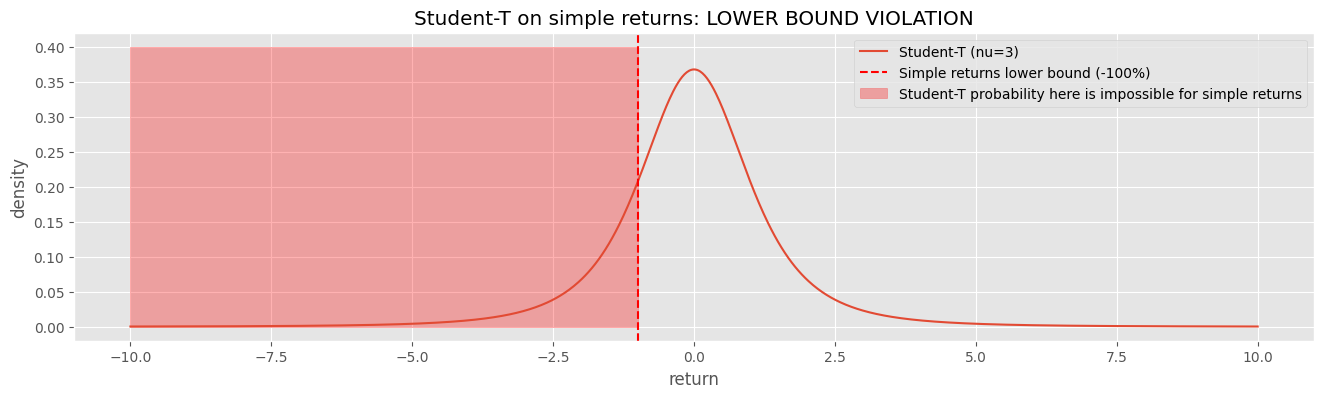

In [ ]:
# Why we need log_return

# Student-T defined on the entire number line (−∞,+∞)
x = np.linspace(-10, 10, 1000)
plt.figure(figsize=(16, 4))
plt.plot(x, t.pdf(x, df=3), label='Student-T (nu=3)')

# Pct returns bound below -1
plt.axvline(x=-1, color='r', linestyle='--', label='Simple returns lower bound (-100%)')
plt.fill_between([-10, -1], 0, 0.4, color='r', alpha=0.3, label='Student-T probability here is impossible for simple returns')

plt.xlabel('return')
plt.ylabel('density')
plt.title('Student-T on simple returns: LOWER BOUND VIOLATION')
plt.legend()

## Bayesian Estimation

### Normal Distribution

In [ ]:
with pm.Model() as normal_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    sigma = pm.HalfNormal('sigma', sigma=0.02)

    returns_obs = pm.Normal('returns_obs', mu=mu, sigma=sigma, observed=df['log_return'])

    trace_normal = pm.sample(2000, tune=1000, chains=4,
                             return_inferencedata=True,
                             idata_kwargs={'log_likelihood': True})

az.plot_trace(trace_normal)

In [ ]:
normal_samples = trace_normal.posterior['sigma'].values.flatten()

In [ ]:
summary = az.summary(trace_normal, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001,0.0,0.000,0.001,0.0,0.0,7638.0,5309.0,1.0
sigma,0.009,0.0,0.009,0.010,0.0,0.0,7797.0,5695.0,1.0


### Laplace's Distribution

In [ ]:
with pm.Model() as laplace_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    b = pm.HalfNormal('b', sigma=0.02)  # scale parameter

    returns_obs = pm.Laplace('returns_obs', mu=mu, b=b, observed=df['log_return'])

    trace_laplace = pm.sample(2000, tune=1000, chains=4,
                              return_inferencedata=True,
                              idata_kwargs={'log_likelihood': True})

az.plot_trace(trace_laplace)

In [ ]:
b_samples = trace_laplace.posterior['b'].values.flatten()
laplace_samples = b_samples * np.sqrt(2) # daily

In [ ]:
summary = az.summary(trace_laplace, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,0.007,0.0,0.006,0.007,0.0,0.0,8399.0,6177.0,1.0
mu,0.001,0.0,0.001,0.001,0.0,0.0,8007.0,5292.0,1.0


### Student Distribution

In [ ]:
with pm.Model() as student_model:
    mu = pm.Normal('mu', mu=0, sigma=.01) # drift
    sigma = pm.HalfNormal('sigma', sigma=.05) # volatility
    nu = pm.Gamma('nu', alpha=2, beta=0.1)  # degrees of freedom, tail thickness

    returns = pm.StudentT('returns', mu=mu, sigma=sigma, nu=nu, observed=df['log_return'])

    trace_student = pm.sample(2000, tune=1000, chains=4,
                              return_inferencedata=True,
                              idata_kwargs={'log_likelihood': True})

az.plot_trace(trace_student)

In [ ]:
summary = az.summary(trace_student, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001,0.000,0.001,0.002,0.000,0.000,6583.0,5652.0,1.0
nu,4.406,0.708,3.166,5.736,0.011,0.009,4284.0,4655.0,1.0
sigma,0.007,0.000,0.006,0.007,0.000,0.000,4384.0,5145.0,1.0


In [ ]:
nu_samples = trace_student.posterior['nu'].values.flatten()
sigma_samples = trace_student.posterior['sigma'].values.flatten()

# Adjustment: true volatility = sigma * sqrt(nu/(nu-2))
# Protection against nu <= 2 (otherwise infinite variance)
nu_safe = np.maximum(nu_samples, 2.01)
student_samples = sigma_samples * np.sqrt(nu_safe / (nu_safe - 2))

### Result

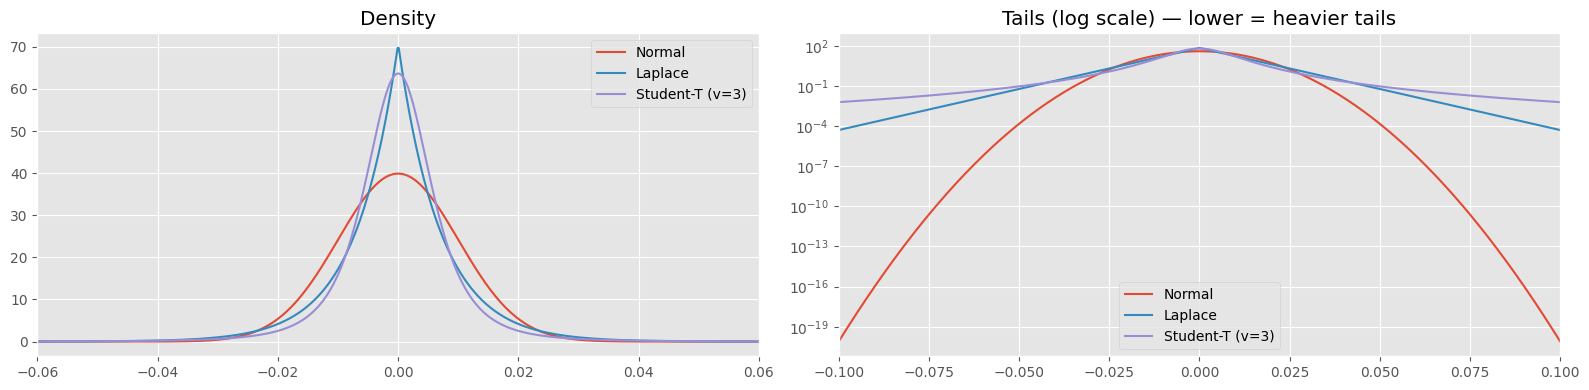

In [ ]:
from scipy.stats import t, laplace, norm

# same volatility (std = 0.01)
target_std = 0.01

# Laplace: b = sigma / sqrt(2) = 0.01 / 1.414 = 0.00707
laplace_b = target_std / np.sqrt(2)

# Student-T: sigma = target_std / sqrt(nu/(nu-2))
nu = 3
student_sigma = target_std / np.sqrt(nu/(nu-2))

x = np.linspace(-0.1, 0.1, 1000)

plt.figure(figsize=(16, 4))

# Subplot 1: density
plt.subplot(1, 2, 1)
plt.plot(x, norm.pdf(x, 0, target_std), label='Normal')
plt.plot(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.plot(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.06, 0.06)
plt.title('Density')
plt.legend()

# Subplot 2: tails (log-scale)
plt.subplot(1, 2, 2)
plt.semilogy(x, norm.pdf(x, 0, target_std), label='Normal')
plt.semilogy(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.semilogy(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.1, 0.1)
plt.title('Tails (log scale) — lower = heavier tails')
plt.legend()

plt.tight_layout()

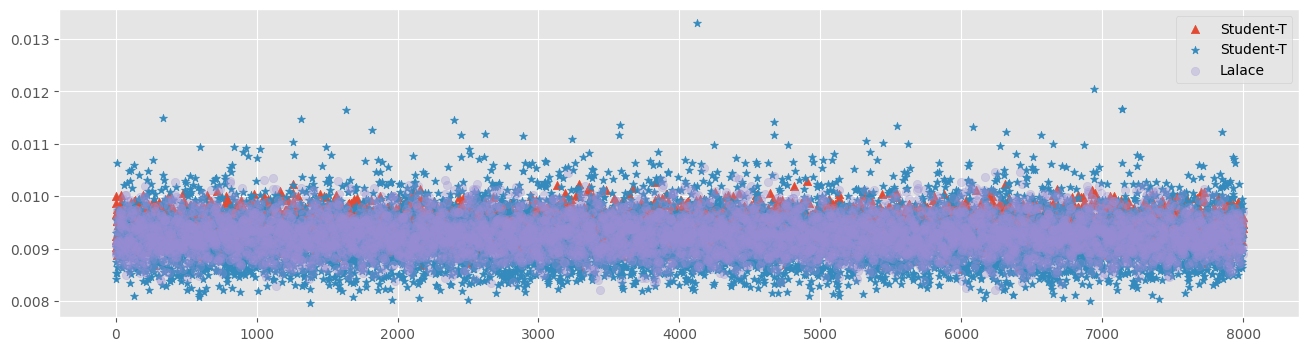

In [ ]:
x = np.arange(8_000)
plt.figure(figsize=(16, 4))
plt.scatter(x, normal_samples, label='Student-T', marker='^')
plt.scatter(x, student_samples, label='Student-T', marker='*')
plt.scatter(x, laplace_samples, label='Lalace', alpha=.3)
plt.legend()

/tmp/ipykernel_6253/4092318433.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot,


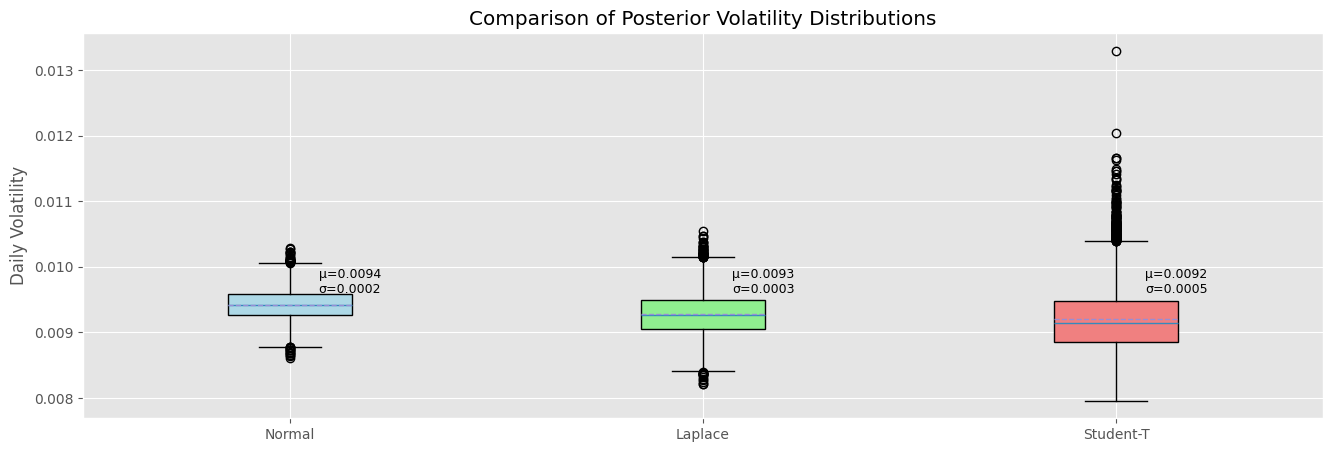

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

data_to_plot = [normal_samples, laplace_samples, student_samples]
bp = ax.boxplot(data_to_plot,
                labels=['Normal', 'Laplace', 'Student-T'],
                patch_artist=True,
                showmeans=True,
                meanline=True)

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Daily Volatility')
ax.set_title('Comparison of Posterior Volatility Distributions')

means = [np.mean(v) for v in data_to_plot]
stds = [np.std(v) for v in data_to_plot]

for i, (mean, std, label) in enumerate(zip(means, stds, ['Normal', 'Laplace', 'Student-T']), 1):
    ax.text(i+.07, 0.0096, f'μ={mean:.4f}\nσ={std:.4f}', fontsize=9)

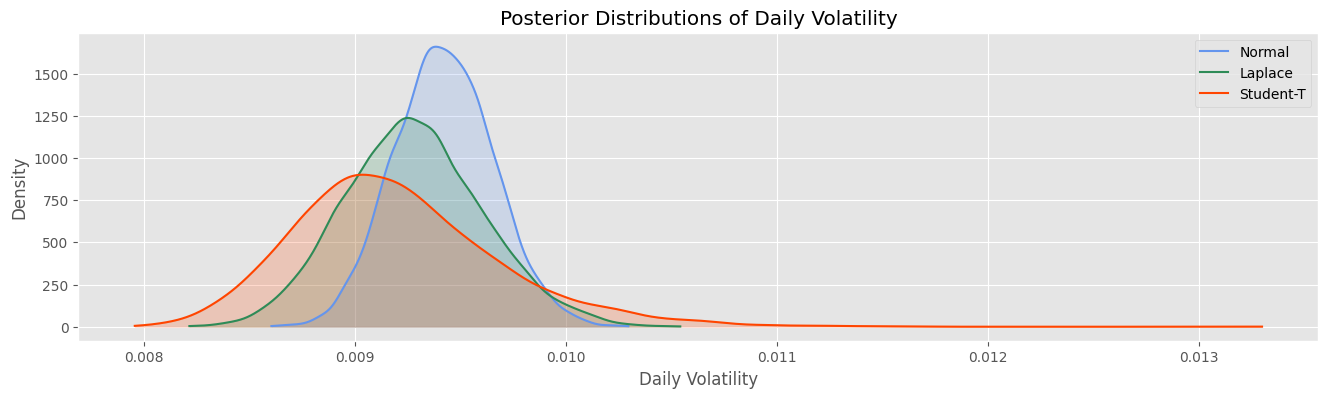

In [ ]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 4))

for vol, label, color in zip([normal_samples, laplace_samples, student_samples],
                             ['Normal', 'Laplace', 'Student-T'],
                             ['cornflowerblue', 'seagreen', 'orangered']):
    kde = gaussian_kde(vol)
    x = np.linspace(vol.min(), vol.max(), 1000)
    ax.plot(x, kde(x), label=label, color=color)
    ax.fill_between(x, kde(x), alpha=0.2, color=color)

ax.set_xlabel('Daily Volatility')
ax.set_ylabel('Density')
ax.set_title('Posterior Distributions of Daily Volatility')
ax.legend()

In [ ]:
comparison_df = pd.DataFrame({
    'MODEL': ['Normal', 'Laplace', 'Student-T'],
    'mean': [np.mean(normal_samples), np.mean(laplace_samples), np.mean(student_samples)],
    'std': [np.std(normal_samples), np.std(laplace_samples), np.std(student_samples)],
    'median': [np.median(normal_samples), np.median(laplace_samples), np.median(student_samples)],
    '95% HDI lower': [
        np.percentile(normal_samples, 2.5),
        np.percentile(laplace_samples, 2.5),
        np.percentile(student_samples, 2.5)
    ],
    '95% HDI upper': [
        np.percentile(normal_samples, 97.5),
        np.percentile(laplace_samples, 97.5),
        np.percentile(student_samples, 97.5)
    ],
    'IQR': [
        np.percentile(normal_samples, 75) - np.percentile(normal_samples, 25),
        np.percentile(laplace_samples, 75) - np.percentile(laplace_samples, 25),
        np.percentile(student_samples, 75) - np.percentile(student_samples, 25)
    ]
})

comparison_df

,MODEL,mean,std,median,95% HDI lower,95% HDI upper,IQR
0,Normal,0.009423,0.000234,0.009421,0.008973,0.009889,0.000320
1,Laplace,0.009279,0.000329,0.009269,0.008663,0.009960,0.000440
2,Student-T,0.009199,0.000491,0.009144,0.008389,0.010331,0.000614


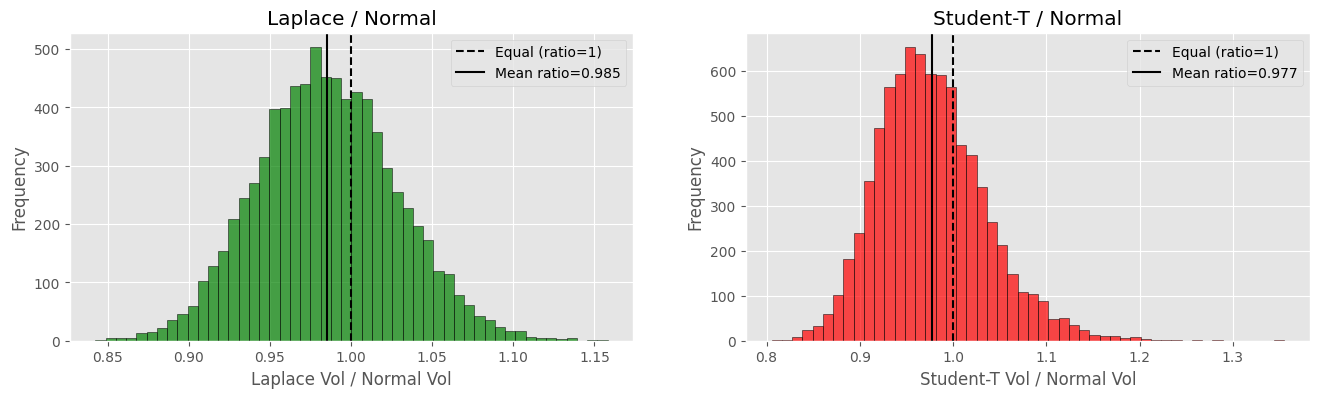

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Laplace / Normal ratio
ratio_ln = laplace_samples / normal_samples
axes[0].hist(ratio_ln, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(x=1, color='black', linestyle='--', label='Equal (ratio=1)')
axes[0].axvline(x=ratio_ln.mean(), color='black', linestyle='-', label=f'Mean ratio={ratio_ln.mean():.3f}')
axes[0].set_xlabel('Laplace Vol / Normal Vol')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Laplace / Normal')
axes[0].legend()

# Student-T / Normal ratio
ratio_sn = student_samples / normal_samples
axes[1].hist(ratio_sn, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(x=1, color='black', linestyle='--', label='Equal (ratio=1)')
axes[1].axvline(x=ratio_sn.mean(), color='black', linestyle='-', label=f'Mean ratio={ratio_sn.mean():.3f}')
axes[1].set_xlabel('Student-T Vol / Normal Vol')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Student-T / Normal')
axes[1].legend()


In [ ]:
comparison = az.compare({
    'Normal': trace_normal,
    'Laplace': trace_laplace,
    'Student-T': trace_student
}, ic='loo')

comparison

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Student-T,0,2786.922482,3.512964,0.000000,0.634647,28.643407,0.000000,False,log
Laplace,1,2780.621178,2.085963,6.301304,0.263261,29.847863,5.320916,False,log
Normal,2,2703.038677,8.616710,83.883805,0.102091,58.609862,42.485231,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

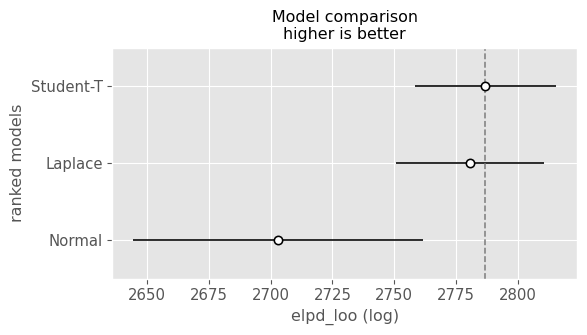

In [ ]:
az.plot_compare(comparison)

In [ ]:
z_score_laplace = comparison.loc['Laplace']['elpd_diff'] / comparison.loc['Laplace']['dse']

z_score_normal = comparison.loc['Normal']['elpd_diff'] / comparison.loc['Normal']['dse']

print(f'Laplace z-score: {z_score_laplace:.1f}')
print(f'Normal z-score:  {z_score_normal:.1f}')

if z_score_laplace > 2:
    print('Laplace significantly worse than Student-T')
if z_score_normal > 2:
    print('Normal significantly worse than Student-T')

Laplace z-score: 1.2
Normal z-score:  2.0


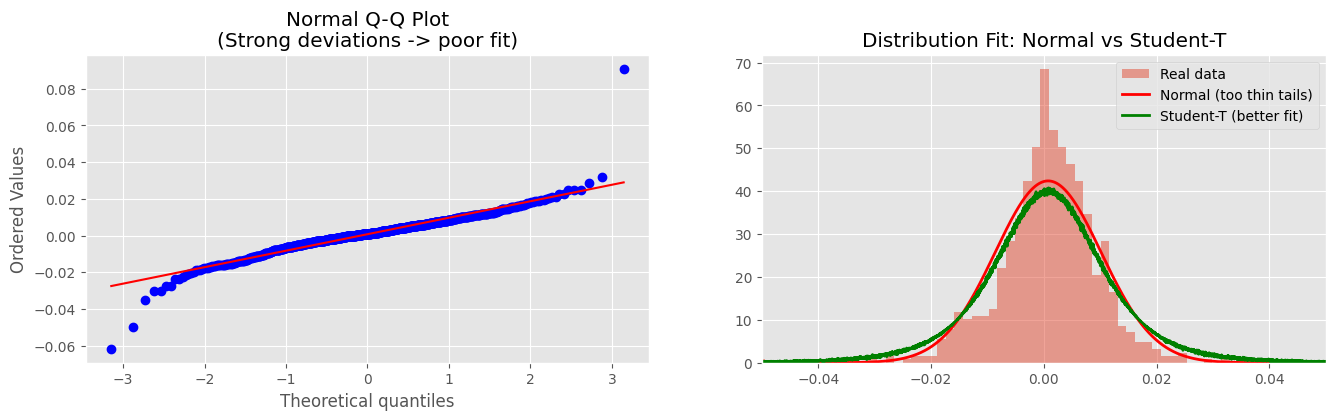

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 1. QQ-plot
from scipy.stats import probplot

probplot(df['log_return'], dist="norm", plot=axes[0])
axes[0].set_title("Normal Q-Q Plot\n(Strong deviations -> poor fit)")

# 2. Плотности
x = np.linspace(df['log_return'].min(), df['log_return'].max(), 8000)

# Normal Model (adjustment)
mu_norm, sigma_norm = df['log_return'].mean(), df['log_return'].std()
norm_pdf = norm.pdf(x, mu_norm, sigma_norm)

# Student-T Model (adjustment)
student_pdf = t.pdf(x, df=nu_samples, loc=df['log_return'].mean(), scale=df['log_return'].std())

axes[1].hist(df['log_return'], bins=100, density=True, alpha=0.5, label='Real data')
axes[1].plot(x, norm_pdf, 'r-', label='Normal (too thin tails)', lw=2)
axes[1].plot(x, student_pdf, 'g-', label='Student-T (better fit)', lw=2)
axes[1].set_xlim(-0.05, 0.05)
axes[1].set_title('Distribution Fit: Normal vs Student-T')
axes[1].legend()

Interpretation:
 - Normal distribution lacks a parameter for tail thickness
 - To Fit heavy-tailed returns, the model artificially increases its effective complexity (p_loo >8)

**Conclusion**: Student-T is better suited for volatility modeling



## Forecasting with Student-T Model

### Train & Test Data

In [3]:
ticker = 'AAPL'
start = dt.datetime(2023, 1, 1)
end = dt.datetime(2025, 1, 1)
interval = '1d'
data = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=True)
data.to_csv('train.csv')

start = dt.datetime(2025, 1, 2)
data = yf.download(ticker, start=start, interval=interval, auto_adjust=True)
data.to_csv('test.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
train = pd.read_csv('train.csv', parse_dates=True, header=[0,1], index_col=0)
train.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096031,128.834011,122.210234,128.223801,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046814,125.753411,122.790923,125.123513,80962700
2023-01-06,127.574226,128.233650,122.918883,124.021209,87754700
2023-01-09,128.095825,131.304382,127.839934,128.410782,70790800


In [5]:
train['log_return'] = np.log(train['Close'].div(train['Close'].shift(1)))
train.dropna(axis=0, inplace=True)
train.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600,0.010261
2023-01-05,123.046814,125.753411,122.790923,125.123513,80962700,-0.010661
2023-01-06,127.574226,128.233650,122.918883,124.021209,87754700,0.036133
2023-01-09,128.095825,131.304382,127.839934,128.410782,70790800,0.004080
2023-01-10,128.666687,129.188321,126.097880,128.204104,63896200,0.004447


In [6]:
test = pd.read_csv('test.csv', parse_dates=True, header=[0,1], index_col=0)
test['log_return'] = np.log(test['Close'].div(test['Close'].shift(1)))
test.dropna(axis=0, inplace=True)
test.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2025-01-03,242.037811,242.853348,240.575797,242.037811,40244100,-0.002012
2025-01-06,243.668900,245.986242,241.878676,242.982646,45045600,0.006716
2025-01-07,240.894073,244.215924,240.038745,241.659879,40856000,-0.011453
2025-01-08,241.381409,242.385931,238.745812,240.605648,37628900,0.002021
2025-01-10,235.563187,238.855201,231.734098,238.706007,61710900,-0.024399


### Model

In [28]:
with pm.Model() as student_model:
    mu = pm.Normal('mu', mu=0, sigma=.01) # drift
    sigma = pm.HalfNormal('sigma', sigma=.05) # volatility
    nu = pm.Gamma('nu', alpha=2, beta=0.1)  # degrees of freedom, tail thickness

    returns = pm.StudentT('returns', mu=mu, sigma=sigma, nu=nu, observed=train['log_return'])

    trace_student = pm.sample(2000, tune=1000, chains=4,
                              return_inferencedata=True,
                              idata_kwargs={'log_likelihood': True})

az.plot_trace(trace_student)

### Basic Approach. Probabilistic Forecast

In [ ]:
N = 30
horizon = 100

mu_samples = trace_student.posterior['mu'].values.flatten()
sigma_samples = trace_student.posterior['sigma'].values.flatten()
nu_samples = trace_student.posterior['nu'].values.flatten()

forecasts = []

for _ in range(N):
    idx = np.random.randint(len(mu_samples))

    mu = mu_samples[idx]
    sigma = sigma_samples[idx]
    nu = nu_samples[idx]

    nu_safe = max(nu, 2.01)
    volatility = sigma * np.sqrt(nu_safe / (nu_safe - 2))

    daily_returns = t.rvs(df=nu, loc=mu, scale=volatility, size=horizon)

    forecasts.append(daily_returns)



forecasts = np.array(forecasts)

print('='*50)
print('100-DAY FORECAST DISTRIBUTION')
print('='*50)

print(f'\tMean forecast: {forecasts.mean():.2%}')
print(f'\t90% CI: [{np.percentile(forecasts, 5):.2%}, {np.percentile(forecasts, 95):.2%}]')
print(f'\tP(negative return): {(forecasts < 0).mean():.1%}')

100-DAY FORECAST DISTRIBUTION
	Mean forecast: 0.15%
	90% CI: [-2.59%, 2.76%]
	P(negative return): 45.6%


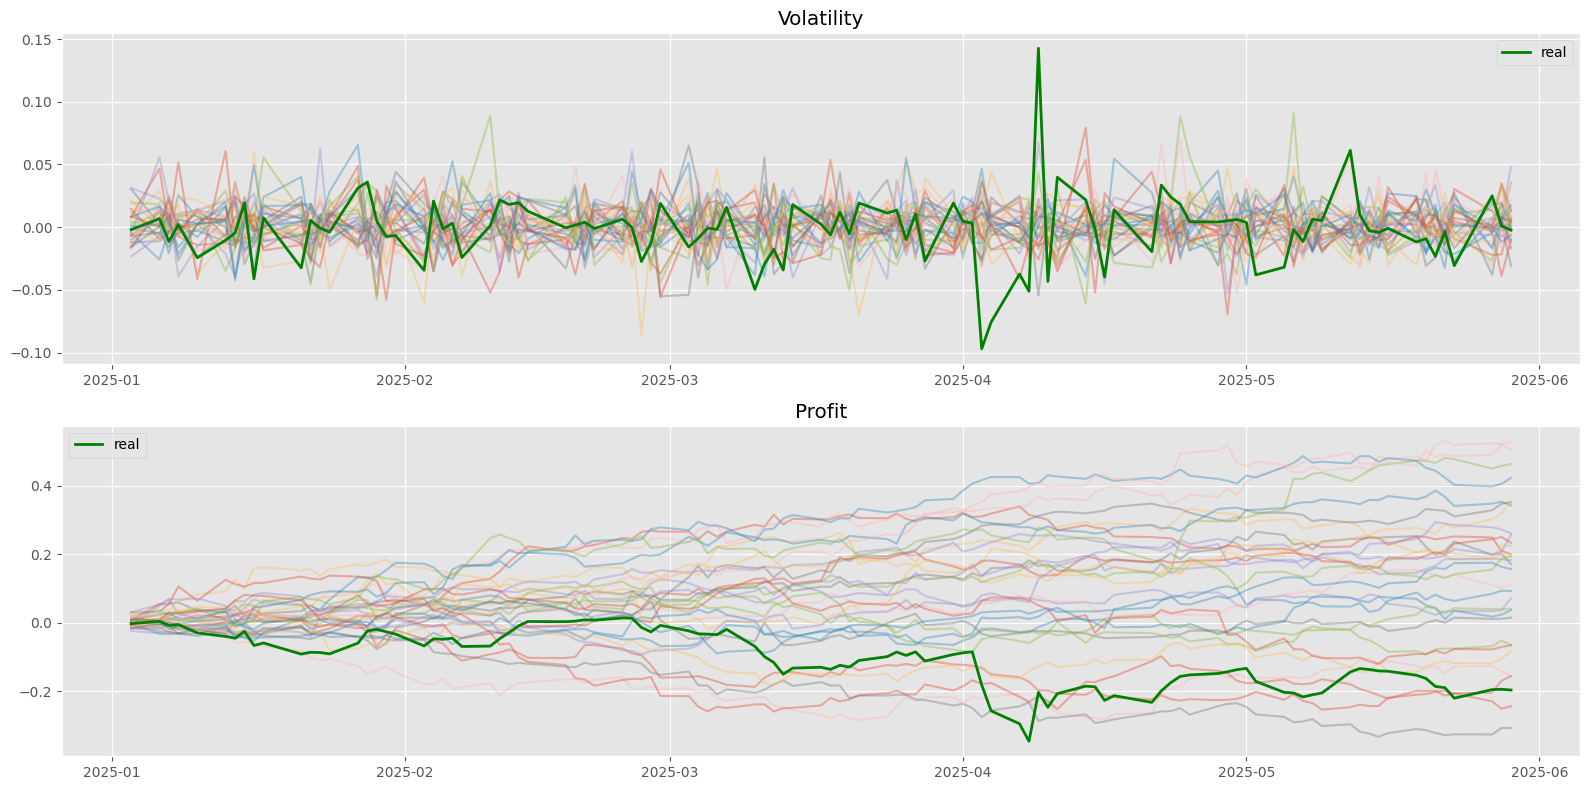

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

for i in range(N):
    axs[0].plot(test.index[:horizon], forecasts[i], alpha=.4)

axs[0].plot(test['log_return'].iloc[:horizon], label='real', lw=2, color='g')
axs[0].set_title('Volatility')
axs[0].legend()

for i in range(N):
    axs[1].plot(test.index[:horizon], forecasts[i].cumsum(), alpha=.4)

axs[1].plot(test['log_return'].iloc[:horizon].cumsum(), label='real', lw=2, color='g')
axs[1].set_title('Profit')
axs[1].legend()


### Value at Risk (VaR) Forecasting

In [15]:
confidence_level=0.95
horizon_days=10
n_forecasts=10_000

mu_samples = trace_student.posterior['mu'].values.flatten()
sigma_samples = trace_student.posterior['sigma'].values.flatten()
nu_samples = trace_student.posterior['nu'].values.flatten()

simulated_returns = []
for _ in range(n_forecasts):
    idx = np.random.randint(len(mu_samples))
    mu = mu_samples[idx]
    sigma = sigma_samples[idx]

    nu = nu_samples[idx]

    nu_safe = max(nu, 2.01)
    volatility = sigma * np.sqrt(nu_safe / (nu_safe - 2))

    ret = t.rvs(df=nu, loc=mu, scale=volatility, size=horizon_days).sum()

    simulated_returns.append(ret)

simulated_returns = np.array(simulated_returns)

# VaR = квантиль распределения потерь
var = np.percentile(simulated_returns, (1 - confidence_level) * 100)

var

np.float64(-0.07258314211048543)

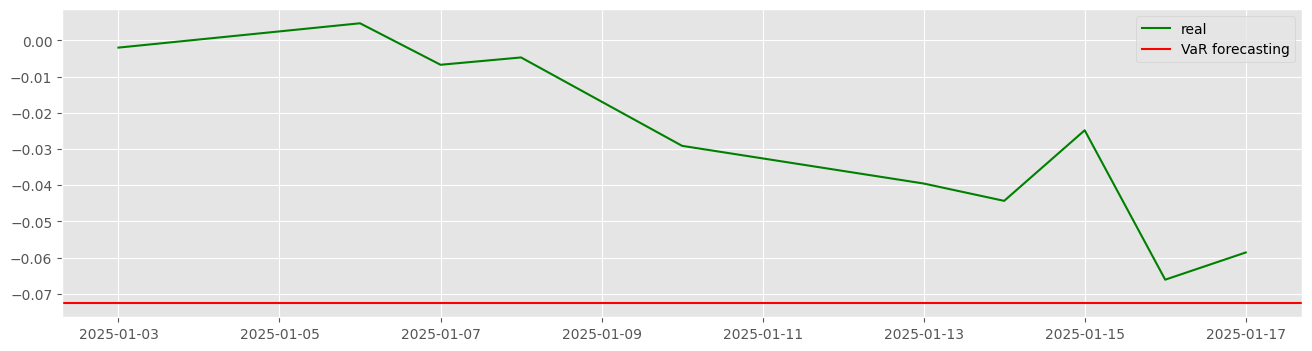

In [24]:
plt.figure(figsize=(16, 4))

plt.plot(test['log_return'].iloc[:horizon_days].cumsum(), c='g', label='real')
plt.axhline(y=var, c='r', label='VaR forecasting')
plt.legend()
